# **معرفی پروژه و بارگذاری فایل شخصی**

# پروژه تحلیل داده و مدل‌سازی مقایسه‌ای Naive Bayes روی دیتاست Diabetes

در این نوت‌بوک، فایل دیتاست واقعی شما (`diabetes.csv`) را بارگذاری کرده و پس از اعمال پیش‌پردازش‌های استاندارد، چندین واریانت مختلف از الگوریتم نایو بیز را آموزش داده و با یکدیگر مقایسه می‌کنیم تا **بهترین مدل** را بر اساس ساختار داده‌ها انتخاب کنیم.

### واریانت‌های مورد بررسی:
1. **Gaussian Naive Bayes (GNB):** فرض بر توزیع نرمال متغیرهای پیوسته دارد.
2. **Multinomial Naive Bayes (MNB):** مناسب برای داده‌های فرکانسی و مثبت (نیازمند مقیاس‌گذاری داده‌های منفی).
3. **Bernoulli Naive Bayes (BNB):** مناسب برای داده‌های دوحالتی و ویژگی‌های دودویی.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.impute import SimpleImputer
import os

# ۱. بارگذاری فایل آپلود شده در گوگل کولب
file_path = 'diabetes.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"[SUCCESS] فایل '{file_path}' با موفقیت بارگذاری شد.")
    print("ابعاد دیتاست:", df.shape)
    display(df.head())
else:
    print(f"[ERROR] فایل '{file_path}' پیدا نشد! لطفا آن را در پنل سمت چپ کولب آپلود کنید.")


[SUCCESS] فایل 'diabetes.csv' با موفقیت بارگذاری شد.
ابعاد دیتاست: (403, 19)


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


# **پیش‌پردازش داده‌ها و اصلاح مقادیر نامعتبر**

## گام دوم: پاکسازی داده‌ها (Data Cleaning) و تعریف متغیر هدف

در این بخش:
1. صفرهای غیرمنطقی در متغیرهای بالینی (مانند قند خون ناشتا `stab.glu` یا کلسترول `chol` در صورت وجود صفر) را به `NaN` تبدیل کرده و با **میانه** جایگزین می‌کنیم.
2. متغیرهای کیفی خالی را با **مد (پر تکرارترین)** پر می‌کنیم.
3. متغیر هدف (`target`) را بر اساس شرط `glyhb > 7.0` برای دیابت ایجاد می‌کنیم.


In [3]:
# کپی از دیتاست برای حفظ داده‌های اصلی
df_clean = df.copy()

# ۱. تعریف متغیر هدف (کلاس ۱ برای دیابتی و ۰ برای سالم)
if 'glyhb' in df_clean.columns:
    df_clean['target'] = (df_clean['glyhb'] > 7.0).astype(int)
    # حذف ستون اصلی glyhb برای جلوگیری از نشت اطلاعات به مدل
    df_clean = df_clean.drop(columns=['glyhb'])
else:
    raise KeyError("ستون 'glyhb' در دیتاست یافت نشد. لطفاً نام ستون‌ها را بررسی کنید.")

# ۲. تبدیل مقادیر صفر غیرمنطقی در ستون‌های عددی به NaN
# ستون‌های عددی کلیدی که مقدار صفر در آن‌ها بی‌معنی است:
clinical_cols = ['stab.glu', 'chol', 'hdl']
for col in clinical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace(0, np.nan)

# ۳. تفکیک ستون‌های عددی و دسته‌ای
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in num_cols: num_cols.remove('target')
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

# ۴. اعمال جایگذاری (Imputation) داده‌های گمشده
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

if num_cols:
    df_clean[num_cols] = num_imputer.fit_transform(df_clean[num_cols])
if cat_cols:
    df_clean[cat_cols] = cat_imputer.fit_transform(df_clean[cat_cols])

# ۵. کدگذاری متغیرهای کیفی به عدد
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# ۶. مقیاس‌گذاری داده‌ها بین 0 و 1 (بسیار مهم برای Multinomial NB که داده منفی قبول نمی‌کند)
scaler = MinMaxScaler()
X = df_clean.drop(columns=['target'])
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
y = df_clean['target']

# تقسیم به مجموعه‌های آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("پیش‌پردازش داده‌ها انجام شد و داده‌ها بین 0 و 1 نرمال‌سازی شدند.")


پیش‌پردازش داده‌ها انجام شد و داده‌ها بین 0 و 1 نرمال‌سازی شدند.


# **مقایسه خودکار مدل‌های مختلف نایو بیز**

## گام سوم: آموزش و انتخاب بهترین واریانت نایو بیز (Model Selection)

در این بخش، سه مدل **Gaussian**، **Multinomial** و **Bernoulli** را بر روی داده‌های آموزش برازش داده و عملکرد آن‌ها را بر روی داده‌های آزمون با استفاده از معیار **F1-Score** (به دلیل احتمال نامتوازن بودن کلاس‌های دیابت) و **Accuracy** مقایسه می‌کنیم. مدلی که بالاترین امتیاز را کسب کند، به عنوان مدل نهایی معرفی می‌شود.


In [5]:
class NaiveBayesClassifierSelector:
    """
    کلاسی برای آموزش، ارزیابی مقایسه‌ای و انتخاب بهترین مدل نایو بیز
    """
    def __init__(self):
        self.models = {
            'Gaussian Naive Bayes (مناسب داده پیوسته)': GaussianNB(),
            'Multinomial Naive Bayes (مناسب داده شمارشی/مثبت)': MultinomialNB(),
            'Bernoulli Naive Bayes (مناسب ویژگی‌های باینری)': BernoulliNB()
        }
        self.best_model_name = None
        self.best_model = None
        self.results = {}

    def fit_and_evaluate(self, X_train, y_train, X_test, y_test):
        best_score = -1

        print("--- شروع فرآیند ارزیابی مدل‌ها --- \n")
        for name, model in self.models.items():
            # آموزش مدل
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            # محاسبه معیارها
            acc = accuracy_score(y_test, preds)
            f1 = f1_score(y_test, preds, average='weighted')

            self.results[name] = {'Accuracy': acc, 'F1-Score': f1}
            print(f"مدل: {name}")
            print(f"   Accuracy: {acc:.4f} | Weighted F1-Score: {f1:.4f}\n")

            # معیار انتخاب: F1-Score (به دلیل نامتوازن بودن متغیر هدف دیابت مناسب‌تر از Accuracy است)
            if f1 > best_score:
                best_score = f1
                self.best_model_name = name
                self.best_model = model

        print("==================================================")
        print(f"🏆 بهترین مدل انتخاب شده: {self.best_model_name}")
        print(f"امتیاز F1 بهترین مدل: {best_score:.4f}")
        print("==================================================")

    def plot_comparison(self):
        """رسم نمودار مقایسه‌ای عملکرد مدل‌ها"""
        df_res = pd.DataFrame(self.results).T
        df_res.plot(kind='bar', figsize=(8, 5))
        plt.title('Comparison of Naive Bayes Variants')
        plt.ylabel('Score')
        plt.ylim(0, 1.1)
        plt.xticks(rotation=15, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()

    def get_best_model_report(self, X_test, y_test):
        """نمایش گزارش نهایی عملکرد بهترین مدل منتخب"""
        preds = self.best_model.predict(X_test)
        print(f"\n--- گزارش عملکرد نهایی برای {self.best_model_name} ---")
        print(classification_report(y_test, preds))

# نمونه‌سازی و اجرای موتور انتخاب مدل
selector = NaiveBayesClassifierSelector()
selector.fit_and_evaluate(X_train, y_train, X_test, y_test)


--- شروع فرآیند ارزیابی مدل‌ها --- 

مدل: Gaussian Naive Bayes (مناسب داده پیوسته)
   Accuracy: 0.8642 | Weighted F1-Score: 0.8702

مدل: Multinomial Naive Bayes (مناسب داده شمارشی/مثبت)
   Accuracy: 0.8519 | Weighted F1-Score: 0.7837

مدل: Bernoulli Naive Bayes (مناسب ویژگی‌های باینری)
   Accuracy: 0.8519 | Weighted F1-Score: 0.7837

🏆 بهترین مدل انتخاب شده: Gaussian Naive Bayes (مناسب داده پیوسته)
امتیاز F1 بهترین مدل: 0.8702


# **رسم نمودار مقایسه‌ای و ارزیابی تفصیلی مدل منتخب**

## گام چهارم: ارزیابی نهایی و تجسم‌سازی عملکرد بهترین مدل

در گام آخر، نمودار مقایسه‌ای امتیاز مدل‌ها را رسم کرده و ماتریس گزارش طبقه‌بندی تفصیلی (شامل Precision، Recall و F1-score هر کلاس) را برای بهترین مدل تولید شده مشاهده می‌کنیم.


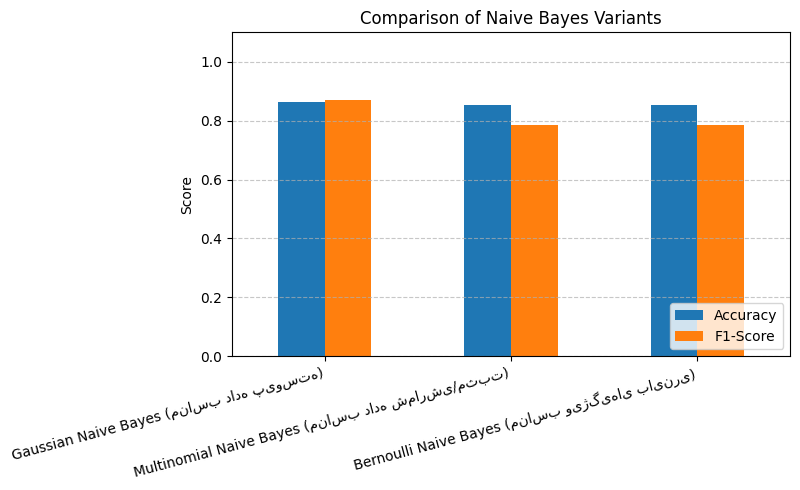


--- گزارش عملکرد نهایی برای Gaussian Naive Bayes (مناسب داده پیوسته) ---
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        69
           1       0.53      0.67      0.59        12

    accuracy                           0.86        81
   macro avg       0.74      0.78      0.76        81
weighted avg       0.88      0.86      0.87        81



In [6]:
# ۱. رسم نمودار مقایسه‌ای مدل‌ها
selector.plot_comparison()

# ۲. چاپ گزارش عملکرد جامع بهترین مدل
selector.get_best_model_report(X_test, y_test)


# **تحلیل عمیق عملکرد مدل برتر**

## گام پنجم: تحلیل عمیق عملکرد مدل برتر (Gaussian Naive Bayes)

با توجه به اینکه مدل **Gaussian Naive Bayes** بهترین عملکرد را با F1-Score برابر با 0.8702 ثبت کرده است، در این بخش ارزیابی‌های پیشرفته‌تری روی آن انجام می‌دهیم:
1. **رسم منحنی ROC و محاسبه AUC:** برای ارزیابی توانایی مدل در تفکیک بیماران دیابتی از افراد سالم در آستانه‌های مختلف تصمیمی.
2. **رسم ماتریس درهم‌ریختگی بهینه‌شده:** جهت مشخص کردن دقیق تعداد خطاهای نوع اول (False Positives) و نوع دوم (False Negatives).
\

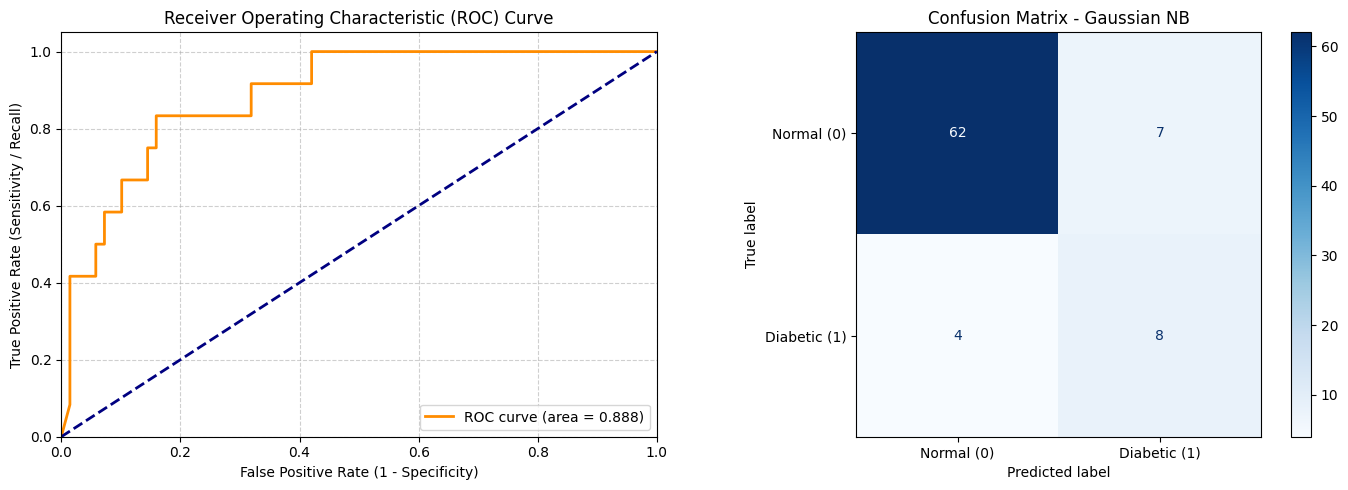

شاخص AUC مدل: 0.8883 (نزدیک‌تر بودن به ۱ نشان‌دهنده قدرت تفکیک عالی مدل است)


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# ۱. استخراج یا آموزش مجدد مدل برتر
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

# ۲. پیش‌بینی احتمال کلاس مثبت (دیابت) برای داده‌های تست
y_probs = gnb_model.predict_proba(X_test)[:, 1]
y_preds = gnb_model.predict(X_test)

# ۳. محاسبه AUC (Area Under Curve)
auc_score = roc_auc_score(y_test, y_probs)

# ۴. رسم نمودارها در یک قاب
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# الف) رسم منحنی ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.3f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate (1 - Specificity)')
ax[0].set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[0].legend(loc="lower right")
ax[0].grid(True, linestyle='--', alpha=0.6)

# ب) رسم ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Diabetic (1)'])
disp.plot(cmap='Blues', ax=ax[1], values_format='d')
ax[1].set_title('Confusion Matrix - Gaussian NB')

plt.tight_layout()
plt.show()

print(f"شاخص AUC مدل: {auc_score:.4f} (نزدیک‌تر بودن به ۱ نشان‌دهنده قدرت تفکیک عالی مدل است)")


# **تفسیر ویژگی‌ها بر اساس پارامترهای مدل**

## گام ششم: تحلیل رفتار مدل و پارامترهای توزیع نرمال ویژگی‌ها

یکی از بزرگترین مزایای الگوریتم Gaussian Naive Bayes، **تفسیرپذیری بالای آن** است. این مدل برای هر ویژگی، یک میانگین ($\mu$) و یک واریانس ($\sigma^2$) به شرط هر کلاس یاد می‌گیرد.
در این بخش، میانگین ویژگی‌های نرمال‌سازی شده را برای دو گروه **سالم (Target = 0)** و **دیابتی (Target = 1)** استخراج کرده و با هم مقایسه می‌کنیم تا مشخص شود مدل چطور ویژگی‌ها را برای تفکیک بیماران ارزیابی می‌کند.


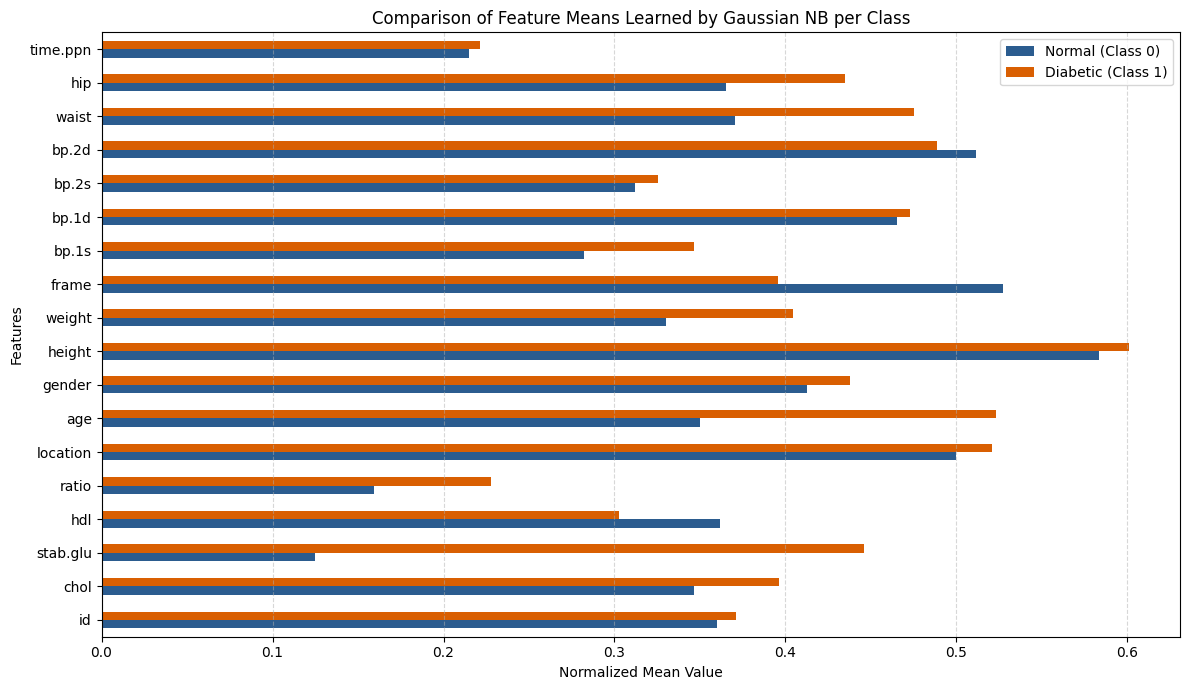

میانگین‌های عددی ویژگی‌ها برای هر کلاس (مقادیر نرمال‌سازی شده بین ۰ و ۱):


,Normal (Class 0),Diabetic (Class 1)
id,0.359779,0.371285
chol,0.346275,0.396119
stab.glu,0.124597,0.445846
hdl,0.361652,0.302469
ratio,0.159231,0.227528
location,0.500000,0.520833
age,0.349915,0.523116
gender,0.412409,0.437500
height,0.583485,0.600694
weight,0.330050,0.404452


In [8]:
# ۱. استخراج میانگین‌های یادگیری شده توسط مدل برای هر کلاس
# gnb_model.theta_ دارای ابعاد (n_classes, n_features) است
means_df = pd.DataFrame(
    gnb_model.theta_,
    columns=X_train.columns,
    index=['Normal (Class 0)', 'Diabetic (Class 1)']
).T

# ۲. رسم نمودار مقایسه‌ای میانگین ویژگی‌ها برای دو کلاس
plt.figure(figsize=(12, 6))
means_df.plot(kind='barh', figsize=(12, 7), color=['#2b5c8f', '#d95f02'], ax=plt.gca())
plt.title('Comparison of Feature Means Learned by Gaussian NB per Class')
plt.xlabel('Normalized Mean Value')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print("میانگین‌های عددی ویژگی‌ها برای هر کلاس (مقادیر نرمال‌سازی شده بین ۰ و ۱):")
display(means_df)


# **تحلیل خطاها و توزیع احتمالات پیش‌بینی**

## گام هفتم: آنالیز خطاها و میزان اطمینان مدل (Prediction Confidence)

برای بهبود مدل در گام‌های بعدی، باید بدانیم در چه مواردی مدل دچار خطا شده است.
در این بخش:
1. توزیع احتمالاتی پیش‌بینی‌های مدل را رسم می‌کنیم تا ببینیم مدل با چه میزان اطمینانی (Confidence) تصمیم‌گیری کرده است.
2. نمونه‌هایی که مدل در پیش‌بینی آن‌ها دچار اشتباه شده (False Positives و False Negatives) را جدا کرده تا مشخص شود خطاها در چه محدوده‌ای رخ می‌دهند.


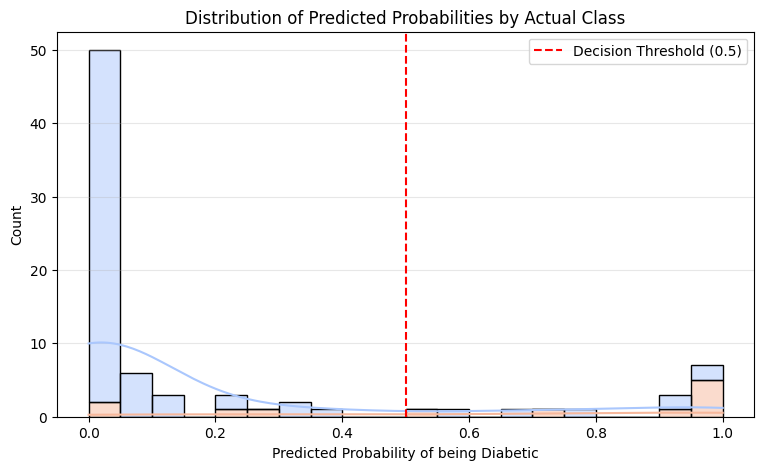

تعداد کل نمونه‌های تست: 81
تعداد خطاهای ثبت شده در پیش‌بینی: 11 (سهم خطا: 13.58%)

نمونه‌هایی از داده‌های تست که مدل در آن‌ها دچار اشتباه شده است (۵ نمونه اول):


,id,chol,stab.glu,hdl,ratio,location,age,gender,height,weight,...,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn,Actual,Predicted,Prob_Diabetic
23,0.006281,0.556164,0.130564,0.268519,0.303371,0.0,0.643836,0.0,0.416667,0.380531,...,0.4250,0.526316,0.390625,0.4375,0.733333,0.411765,0.180064,0,1,0.769879
349,0.499534,0.386301,0.243323,0.296296,0.196629,1.0,0.356164,1.0,0.625000,0.526549,...,0.5125,0.815789,0.453125,0.7500,0.500000,0.441176,0.112540,1,0,0.253565
248,0.411743,0.435616,0.207715,0.305556,0.213483,0.0,0.739726,0.0,0.500000,0.331858,...,0.4500,0.355263,0.304688,0.5000,0.400000,0.411765,0.189711,1,0,0.224950
376,0.981475,0.408219,0.109792,0.129630,0.404494,1.0,0.534247,1.0,0.750000,0.495575,...,0.3375,0.447368,0.265625,0.3125,0.400000,0.382353,0.305466,0,1,0.939658
194,0.356905,0.178082,0.958457,0.314815,0.089888,1.0,0.671233,1.0,0.625000,0.261062,...,0.3000,0.447368,0.304688,0.5000,0.366667,0.382353,0.054662,0,1,1.000000


In [9]:
# ۱. ساخت دیتاست تحلیل خطا روی داده‌های تست
analysis_df = pd.DataFrame(X_test.copy())
analysis_df['Actual'] = y_test.values
analysis_df['Predicted'] = y_preds
analysis_df['Prob_Diabetic'] = y_probs

# شناسایی نمونه‌های پیش‌بینی اشتباه
errors = analysis_df[analysis_df['Actual'] != analysis_df['Predicted']]

# ۲. رسم هیستوگرام توزیع احتمالات پیش‌بینی‌شده برای بررسی اطمینان مدل
plt.figure(figsize=(9, 5))
sns.histplot(data=analysis_df, x='Prob_Diabetic', hue='Actual', bins=20, kde=True, multiple='stack', palette='coolwarm')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title('Distribution of Predicted Probabilities by Actual Class')
plt.xlabel('Predicted Probability of being Diabetic')
plt.ylabel('Count')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"تعداد کل نمونه‌های تست: {len(X_test)}")
print(f"تعداد خطاهای ثبت شده در پیش‌بینی: {len(errors)} (سهم خطا: {len(errors)/len(X_test)*100:.2f}%)")
if len(errors) > 0:
    print("\nنمونه‌هایی از داده‌های تست که مدل در آن‌ها دچار اشتباه شده است (۵ نمونه اول):")
    display(errors.head())
